# Optimisation de portefeuille CAC40 — Pipeline complet

Ce notebook couvre :
1. Téléchargement des données CAC40 via yfinance
2. Calcul des rendements et statistiques
3. Optimisation SGD (mean-variance avec actif sans risque)
4. Backtest et métriques de performance
5. Comparaison des stratégies
6. Visualisations

## 0. Imports

In [1]:
import sys
import os
import joblib
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date
import matplotlib.dates as mdates

sys.path.append(os.path.abspath('..'))


from ext.portfolio_math import (
    estimate_expected_returns,
    estimate_covariance_matrix,
    add_risk_free_asset,
    split_weights,
    mean_variance_cost,
    mean_variance_gradient,
    enforce_portfolio_constraints,
)
from ext.sgd_optimizer import initialize_weights, run_sgd
from ext.portfolio_backtest import (
    run_static_backtest,
    run_portfolio_backtest,
    compare_strategies,
)
from ext.ml_signals import build_ml_signals

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('Imports OK')

Imports OK


## 1. Données CAC40

In [2]:
# Sous-ensemble représentatif du CAC40 — 12 actions couvrant plusieurs secteurs
# Luxe / Conso : MC.PA, RMS.PA, OR.PA
# Industrie    : AIR.PA, SAN.PA, DG.PA
# Banque / Assu: BNP.PA, ACA.PA, CS.PA
# Energie / Util: TTE.PA, EDF.PA, EN.PA

TICKERS = [
    'MC.PA',   # LVMH
    'RMS.PA',  # Hermès
    'OR.PA',   # L'Oréal
    'AIR.PA',  # Airbus
    'SAN.PA',  # Sanofi
    'DG.PA',   # Vinci
    'BNP.PA',  # BNP Paribas
    'ACA.PA',  # Crédit Agricole
    'TTE.PA',  # TotalEnergies
    'EN.PA',   # Bouygues
    'VIE.PA',  # Veolia
    'CAP.PA',  # Capgemini
]

START_DATE      = '2019-01-01'
END_DATE        = '2024-01-01'
RISK_FREE_RATE  = 0.03   # taux OAT 10 ans approx annuel
ANNUALIZATION   = 252

print(f'{len(TICKERS)} actifs | {START_DATE} → {END_DATE}')
print(f'Taux sans risque : {RISK_FREE_RATE:.1%} annuel')

12 actifs | 2019-01-01 → 2024-01-01
Taux sans risque : 3.0% annuel


In [3]:
# Téléchargement des prix de clôture ajustés
raw = yf.download(TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
price_data = raw['Close'].dropna(how='all')

# Supprimer les actifs avec trop de données manquantes (> 5%)
missing_pct = price_data.isnull().mean()
tickers_ok  = missing_pct[missing_pct < 0.05].index.tolist()
price_data  = price_data[tickers_ok].ffill().dropna()

print(f'Actifs retenus   : {len(tickers_ok)}')
print(f'Période effective: {price_data.index[0].date()} → {price_data.index[-1].date()}')
print(f'Nombre de jours  : {len(price_data)}')
price_data.tail(3)

Actifs retenus   : 12
Période effective: 2019-01-02 → 2023-12-29
Nombre de jours  : 1283


Ticker,ACA.PA,AIR.PA,BNP.PA,CAP.PA,DG.PA,EN.PA,MC.PA,OR.PA,RMS.PA,SAN.PA,TTE.PA,VIE.PA
Date,,,,,,,,,,,,
2023-12-27,11.292180,131.589706,53.623352,183.772797,102.488770,29.613754,693.504456,425.676270,1869.431763,82.003822,54.565109,26.314655
2023-12-28,11.243213,131.835114,53.163647,182.522644,101.700668,29.527468,689.355103,428.142853,1851.218140,82.086586,53.639244,26.250517
2023-12-29,11.237967,131.929504,53.282825,181.512894,101.826050,29.441181,691.807068,427.526184,1858.968506,82.546410,53.805206,26.168055


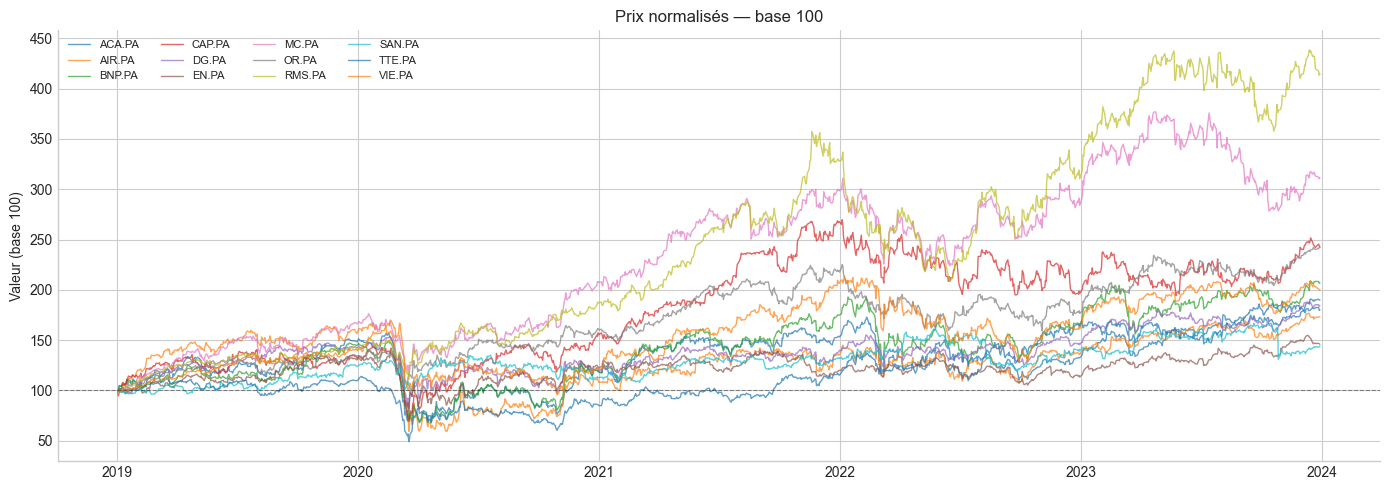

In [4]:
# Visualisation des prix normalisés (base 100)
fig, ax = plt.subplots(figsize=(14, 5))
normalized = price_data / price_data.iloc[0] * 100
for col in normalized.columns:
    ax.plot(normalized.index, normalized[col], linewidth=1, alpha=0.7, label=col)
ax.axhline(100, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax.set_title('Prix normalisés — base 100')
ax.set_ylabel('Valeur (base 100)')
ax.legend(ncol=4, fontsize=8, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 2. Rendements et statistiques

In [5]:
# Rendements journaliers simples
returns_matrix = price_data.pct_change().dropna()

# Séparation train / test (80% / 20%)
split_idx    = int(len(returns_matrix) * 0.8)
returns_train = returns_matrix.iloc[:split_idx]
returns_test  = returns_matrix.iloc[split_idx:]
price_test    = price_data.iloc[split_idx:]

print(f'Train : {returns_train.index[0].date()} → {returns_train.index[-1].date()} ({len(returns_train)} jours)')
print(f'Test  : {returns_test.index[0].date()}  → {returns_test.index[-1].date()} ({len(returns_test)} jours)')

Train : 2019-01-03 → 2022-12-28 (1025 jours)
Test  : 2022-12-29  → 2023-12-29 (257 jours)


In [6]:
# Statistiques descriptives annualisées (sur train)
mu    = estimate_expected_returns(returns_train)
Sigma = estimate_covariance_matrix(returns_train)

stats = pd.DataFrame({
    'Rendement annualisé (%)' : mu * ANNUALIZATION * 100,
    'Volatilité annualisée (%)': np.sqrt(np.diag(Sigma) * ANNUALIZATION) * 100,
    'Sharpe individuel'        : (mu * ANNUALIZATION - RISK_FREE_RATE) /
                                  (np.sqrt(np.diag(Sigma) * ANNUALIZATION)),
}, index=tickers_ok)

stats.sort_values('Sharpe individuel', ascending=False).round(3)

,Rendement annualisé (%),Volatilité annualisée (%),Sharpe individuel
RMS.PA,31.933,27.512,1.052
MC.PA,30.356,29.823,0.917
CAP.PA,21.851,32.751,0.576
OR.PA,17.239,25.038,0.569
TTE.PA,18.025,33.662,0.446
BNP.PA,19.436,37.503,0.438
VIE.PA,16.525,31.080,0.435
DG.PA,14.746,33.026,0.356
SAN.PA,10.619,22.259,0.342
AIR.PA,17.967,45.413,0.330


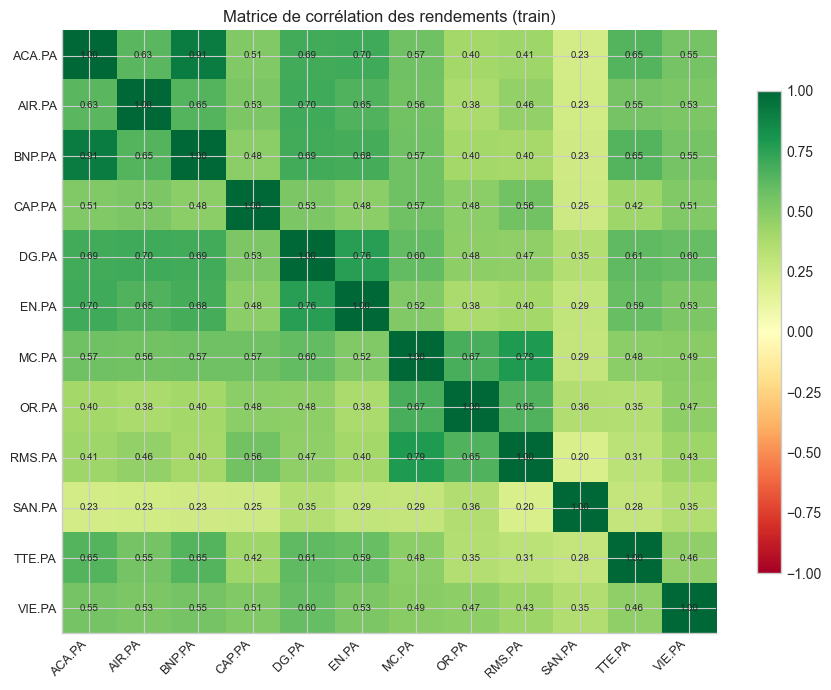

In [7]:
# Matrice de corrélation
corr = returns_train.corr()
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(tickers_ok)))
ax.set_yticks(range(len(tickers_ok)))
ax.set_xticklabels(tickers_ok, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(tickers_ok, fontsize=9)
plt.colorbar(im, ax=ax, shrink=0.8)
for i in range(len(tickers_ok)):
    for j in range(len(tickers_ok)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=7)
ax.set_title('Matrice de corrélation des rendements (train)')
plt.tight_layout()
plt.show()

## 3. Optimisation SGD

In [8]:
# Extension avec actif sans risque
rf_daily = RISK_FREE_RATE / ANNUALIZATION
mu_ext, Sigma_ext = add_risk_free_asset(mu, Sigma, rf_daily)

n_assets = len(mu_ext)  # N actifs risqués + 1 sans risque
print(f'Dimension du vecteur de poids : {n_assets} ({n_assets-1} actifs + 1 sans risque)')

Dimension du vecteur de poids : 13 (12 actifs + 1 sans risque)


In [9]:
# Paramètres SGD
SGD_PARAMS = dict(
    n_iterations          = 1000,
    learning_rate         = 0.05,
    convergence_window    = 10,
    convergence_tolerance = 1e-7,
    verbose               = True,
)

# Paramètres de la fonction de coût — passés via **kwargs à cost_function et gradient_function
COST_PARAMS = dict(
    expected_returns     = mu_ext,
    covariance_matrix    = Sigma_ext,
    lambda_risk          = 2.0,
    annualization_factor = ANNUALIZATION,
)


# Initialisation equal weight
w0 = initialize_weights(n_assets, method='equal')

# Lancement
results_sgd = run_sgd(
    cost_function       = mean_variance_cost,
    initial_weights     = w0,
    constraint_function = enforce_portfolio_constraints,
    gradient_function   = mean_variance_gradient,
    **SGD_PARAMS,   # n_iterations, learning_rate, etc. → paramètres nommés de run_sgd
    **COST_PARAMS,  # expected_returns, covariance_matrix, etc. → **kwargs → cost/gradient
)


Iteration 0 - Cost: -0.091779
Convergence reached at iteration 12.


In [10]:
# Résultats de l'optimisation
print(f"Convergé        : {results_sgd['converged']}")
print(f"Itérations      : {results_sgd['n_iterations']}")
print(f"Coût final      : {results_sgd['cost_history'][-1]:.6f}")

# Séparation des poids
w_risques, w_rf = split_weights(results_sgd['final_weights'])

print(f"\nPart sans risque : {w_rf:.2%}")
print()

# Affichage des poids optimisés
poids_df = pd.DataFrame({
    'Actif' : tickers_ok,
    'Poids (%)': w_risques * 100
}).sort_values('Poids (%)', ascending=False)
print(poids_df.to_string(index=False))

Convergé        : True
Itérations      : 13
Coût final      : -0.092379

Part sans risque : 1.35%

 Actif  Poids (%)
RMS.PA  14.345341
 MC.PA  13.627005
CAP.PA   9.798952
BNP.PA   8.700287
TTE.PA   8.076598
AIR.PA   8.029596
 OR.PA   7.734040
VIE.PA   7.403716
 DG.PA   6.593710
ACA.PA   5.983228
SAN.PA   4.767307
 EN.PA   3.589284


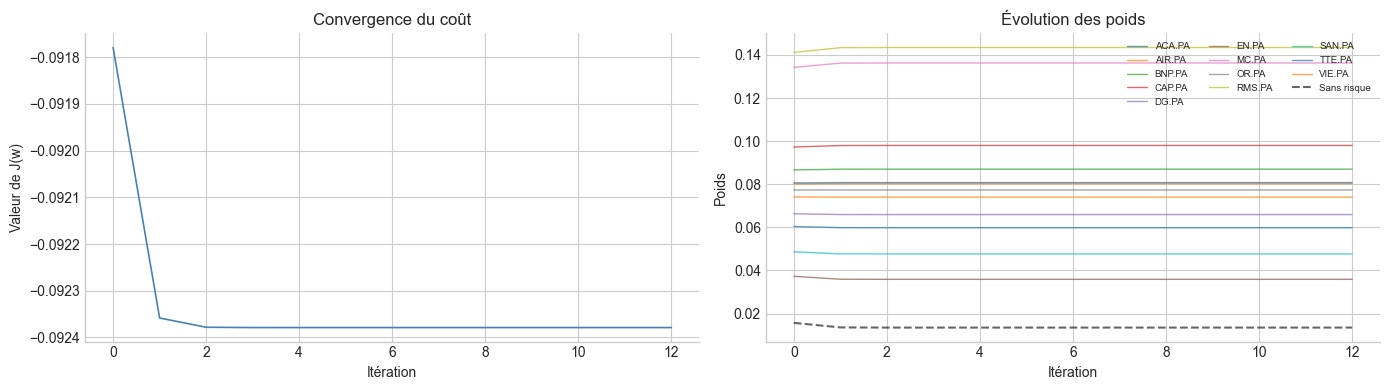

In [11]:
# Courbe de convergence du SGD
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Coût
axes[0].plot(results_sgd['cost_history'], color='steelblue', linewidth=1.2)
axes[0].set_title('Convergence du coût')
axes[0].set_xlabel('Itération')
axes[0].set_ylabel('Valeur de J(w)')

# Évolution des poids dans le temps
weights_hist = np.array(results_sgd['weights_history'])
for i, ticker in enumerate(tickers_ok):
    axes[1].plot(weights_hist[:, i], linewidth=1, alpha=0.7, label=ticker)
axes[1].plot(weights_hist[:, -1], linewidth=1.5, linestyle='--',
             color='black', alpha=0.6, label='Sans risque')
axes[1].set_title('Évolution des poids')
axes[1].set_xlabel('Itération')
axes[1].set_ylabel('Poids')
axes[1].legend(ncol=3, fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()

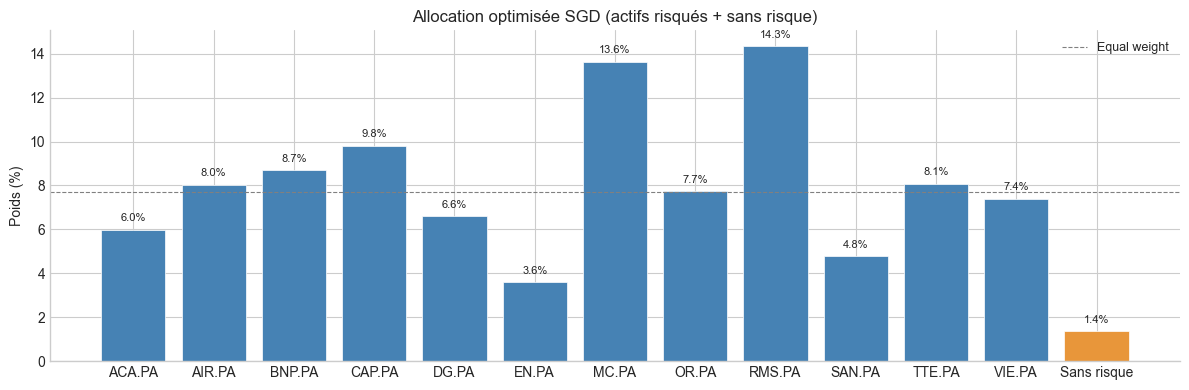

In [12]:
# Allocation finale — graphique en barres
labels = tickers_ok + ['Sans risque']
poids_finaux = np.append(w_risques, w_rf)
colors = ['steelblue'] * len(tickers_ok) + ['#E8963A']

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(labels, poids_finaux * 100, color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(100 / (len(tickers_ok) + 1), color='gray', linestyle='--',
           linewidth=0.8, label='Equal weight')
for bar, val in zip(bars, poids_finaux):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1%}', ha='center', va='bottom', fontsize=8)
ax.set_title('Allocation optimisée SGD (actifs risqués + sans risque)')
ax.set_ylabel('Poids (%)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4. Signaux ML dynamiques

In [15]:
# Construction des signaux sur les données d'entraînement
ml_results = build_ml_signals(
    price_data   = price_data,
    window       = 20,
    method       = 'momentum_volatility',
    long_only    = True,
    fallback     = 'equal',
    align_for_backtest = True,
)

dynamic_weights = ml_results['weights_for_backtest']
# Restreindre à la période de test
dynamic_weights_test = dynamic_weights.loc[
    dynamic_weights.index.intersection(returns_test.index)
]

print(f'Poids dynamiques : {dynamic_weights_test.shape[0]} dates × {dynamic_weights_test.shape[1]} actifs')
dynamic_weights_test.describe().round(4)

Poids dynamiques : 257 dates × 12 actifs


Ticker,ACA.PA,AIR.PA,BNP.PA,CAP.PA,DG.PA,EN.PA,MC.PA,OR.PA,RMS.PA,SAN.PA,TTE.PA,VIE.PA
count,257.0000,257.0000,257.0000,257.0000,257.0000,257.0000,257.0000,257.0000,257.0000,257.0000,257.0000,257.0000
mean,0.1311,0.0886,0.0786,0.0659,0.0696,0.0934,0.0442,0.0716,0.0726,0.0964,0.1185,0.0696
std,0.1379,0.1133,0.0743,0.0926,0.0742,0.1075,0.0549,0.0947,0.0897,0.1511,0.2033,0.0760
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,0.1102,0.0695,0.0741,0.0294,0.0497,0.0618,0.0169,0.0333,0.0536,0.0282,0.0067,0.0686
75%,0.1935,0.1234,0.1251,0.0980,0.1303,0.1578,0.0810,0.1131,0.1196,0.1393,0.1425,0.1083
max,0.7532,0.8536,0.3436,0.5604,0.3304,0.5757,0.2898,0.4452,0.5548,1.0000,1.0000,0.3625


## 5. Backtest — période de test

In [16]:
# Backtest des trois stratégies sur la période de TEST
backtest_results = run_portfolio_backtest(
    returns_matrix      = returns_test,
    optimized_weights   = w_risques,
    w_rf                = w_rf,
    dynamic_weights     = dynamic_weights_test,
    initial_value       = 1.0,
    risk_free_rate      = RISK_FREE_RATE,
    annualization_factor= ANNUALIZATION,
)

print('Tableau comparatif des stratégies :')
print()
print(backtest_results['comparison'].round(4).to_string())

Tableau comparatif des stratégies :

              cumulative_return  volatility  theoretical_volatility  sharpe_ratio  max_drawdown
equal_weight             0.2417      0.1413                  0.1413        1.4272       -0.0786
optimized                0.2343      0.1515                  0.1515        1.3064       -0.0853
dynamic                  0.1251      0.1335                     NaN        0.7372       -0.0833


## 6. Visualisations des performances

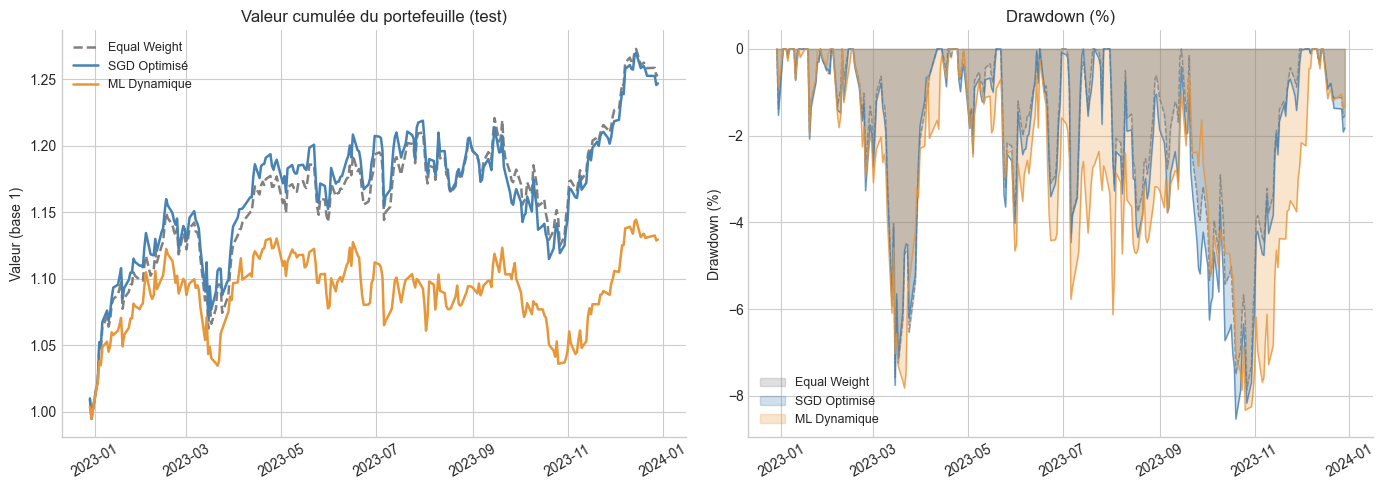

In [17]:
# Valeurs cumulées des trois stratégies
strategy_results = backtest_results['strategy_results']

LABELS = {
    'equal_weight': ('Equal Weight',  'gray',      '--'),
    'optimized'   : ('SGD Optimisé',  'steelblue', '-'),
    'dynamic'     : ('ML Dynamique',  '#E8963A',   '-'),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Valeur du portefeuille
for key, (label, color, ls) in LABELS.items():
    if key in strategy_results:
        pv = strategy_results[key]['portfolio_value']
        axes[0].plot(pv.index, pv.values, label=label,
                     color=color, linestyle=ls, linewidth=1.8)
axes[0].set_title('Valeur cumulée du portefeuille (test)')
axes[0].set_ylabel('Valeur (base 1)')
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

# Drawdown
for key, (label, color, ls) in LABELS.items():
    if key in strategy_results:
        pv    = strategy_results[key]['portfolio_value']
        roll_max = pv.cummax()
        dd    = (pv - roll_max) / roll_max * 100
        axes[1].fill_between(dd.index, dd.values, 0,
                              alpha=0.25, color=color, label=label)
        axes[1].plot(dd.index, dd.values, color=color, linestyle=ls,
                     linewidth=1, alpha=0.8)
axes[1].set_title('Drawdown (%)')
axes[1].set_ylabel('Drawdown (%)')
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()

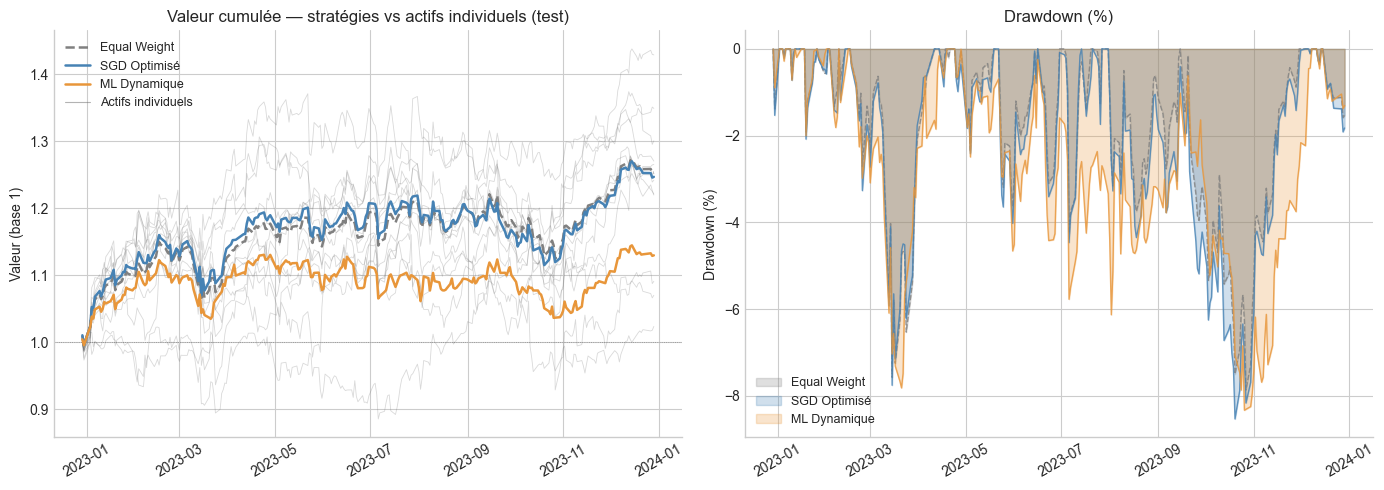

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Valeur cumulée des stratégies + prix réels normalisés ---
for key, (label, color, ls) in LABELS.items():
    if key in strategy_results:
        pv = strategy_results[key]['portfolio_value']
        axes[0].plot(pv.index, pv.values, label=label,
                     color=color, linestyle=ls, linewidth=1.8, zorder=3)

# Prix réels normalisés (base 1) sur la période de test
price_test_norm = price_data.loc[returns_test.index] 
price_test_norm = price_test_norm / price_test_norm.iloc[0]  # base 1 comme les stratégies

for col in price_test_norm.columns:
    axes[0].plot(price_test_norm.index, price_test_norm[col],
                 linewidth=0.6, alpha=0.25, color='dimgray', zorder=1)

# Une seule entrée de légende pour tous les actifs individuels
axes[0].plot([], [], linewidth=0.8, alpha=0.5, color='dimgray', label='Actifs individuels')

axes[0].axhline(1, color='black', linewidth=0.6, linestyle=':', alpha=0.3)
axes[0].set_title('Valeur cumulée — stratégies vs actifs individuels (test)')
axes[0].set_ylabel('Valeur (base 1)')
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

# --- Drawdown ---
for key, (label, color, ls) in LABELS.items():
    if key in strategy_results:
        pv       = strategy_results[key]['portfolio_value']
        roll_max = pv.cummax()
        dd       = (pv - roll_max) / roll_max * 100
        axes[1].fill_between(dd.index, dd.values, 0,
                             alpha=0.25, color=color, label=label)
        axes[1].plot(dd.index, dd.values, color=color, linestyle=ls,
                     linewidth=1, alpha=0.8)

axes[1].set_title('Drawdown (%)')
axes[1].set_ylabel('Drawdown (%)')
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()


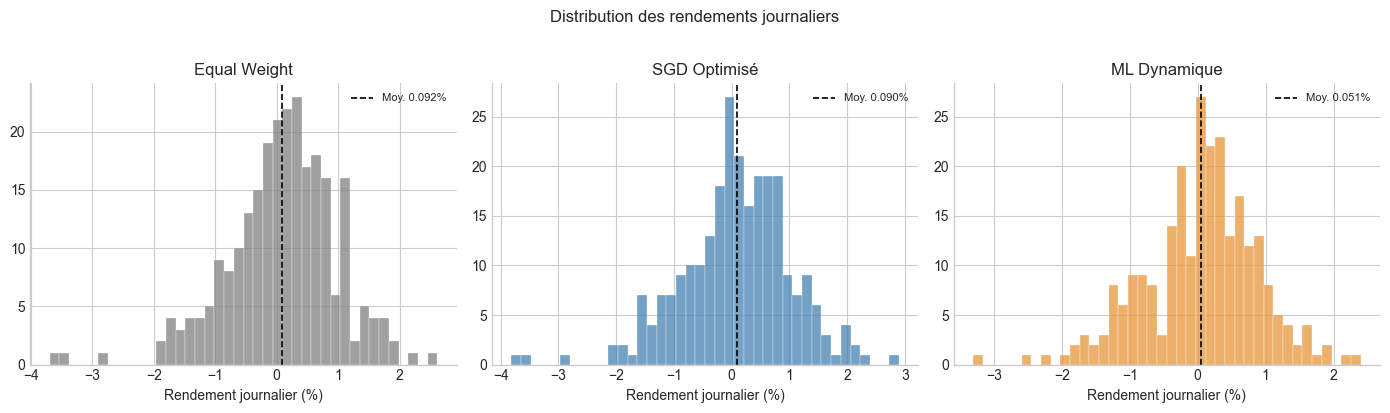

In [18]:
# Rendements journaliers — distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (key, (label, color, _)) in zip(axes, LABELS.items()):
    if key not in strategy_results:
        continue
    r = strategy_results[key]['portfolio_returns'] * 100
    ax.hist(r, bins=40, color=color, alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(r.mean(), color='black', linewidth=1.2, linestyle='--',
               label=f'Moy. {r.mean():.3f}%')
    ax.set_title(label)
    ax.set_xlabel('Rendement journalier (%)')
    ax.legend(fontsize=8)

plt.suptitle('Distribution des rendements journaliers', y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# Tableau récapitulatif final formaté
comparison = backtest_results['comparison'].copy()
comparison.columns = [
    'Rendement cumulé', 'Volatilité', 'Volatilité théorique',
    'Ratio de Sharpe', 'Max Drawdown'
]
fmt = {
    'Rendement cumulé'    : '{:.2%}',
    'Volatilité'          : '{:.2%}',
    'Volatilité théorique': lambda x: f'{x:.2%}' if pd.notna(x) else '—',
    'Ratio de Sharpe'     : '{:.2f}',
    'Max Drawdown'        : '{:.2%}',
}
comparison.style.format(fmt).set_caption('Résumé des performances — période de test')

,Rendement cumulé,Volatilité,Volatilité théorique,Ratio de Sharpe,Max Drawdown
equal_weight,24.17%,14.13%,14.13%,1.43,-7.86%
optimized,23.43%,15.15%,15.15%,1.31,-8.53%
dynamic,12.51%,13.35%,—,0.74,-8.33%


## 7. Analyse de sensibilité — lambda_risk

In [20]:
# Impact du paramètre d'aversion au risque sur les poids et les performances
lambdas   = [0.5, 1.0, 2.0, 5.0, 10.0]
sens_rows = []

for lam in lambdas:
    res = run_sgd(
        cost_function       = mean_variance_cost,
        initial_weights     = w0,
        n_iterations        = 500,
        learning_rate       = 0.05,
        constraint_function = enforce_portfolio_constraints,
        gradient_function   = mean_variance_gradient,
        convergence_window  = 10,
        verbose             = False,
        expected_returns    = mu_ext,
        covariance_matrix   = Sigma_ext,
        lambda_risk         = lam,
        annualization_factor= ANNUALIZATION,
    )
    wr, wrf = split_weights(res['final_weights'])
    bt = run_static_backtest(
        returns_matrix      = returns_test,
        weights             = wr,
        w_rf                = wrf,
        risk_free_rate      = RISK_FREE_RATE,
        annualization_factor= ANNUALIZATION,
    )
    sens_rows.append({
        'lambda_risk'      : lam,
        'w_rf (%)'         : wrf * 100,
        'Rendement cumulé' : bt['cumulative_return'],
        'Volatilité'       : bt['volatility'],
        'Sharpe'           : bt['sharpe_ratio'],
        'Max Drawdown'     : bt['max_drawdown'],
    })

sens_df = pd.DataFrame(sens_rows).set_index('lambda_risk')
sens_df.round(4)

,w_rf (%),Rendement cumulé,Volatilité,Sharpe,Max Drawdown
lambda_risk,,,,,
0.5,1.3460,0.2344,0.1515,1.3070,-0.0853
1.0,1.3476,0.2343,0.1515,1.3068,-0.0853
2.0,1.3509,0.2343,0.1515,1.3064,-0.0853
5.0,1.3609,0.2342,0.1516,1.3053,-0.0854
10.0,1.3778,0.2339,0.1517,1.3034,-0.0856


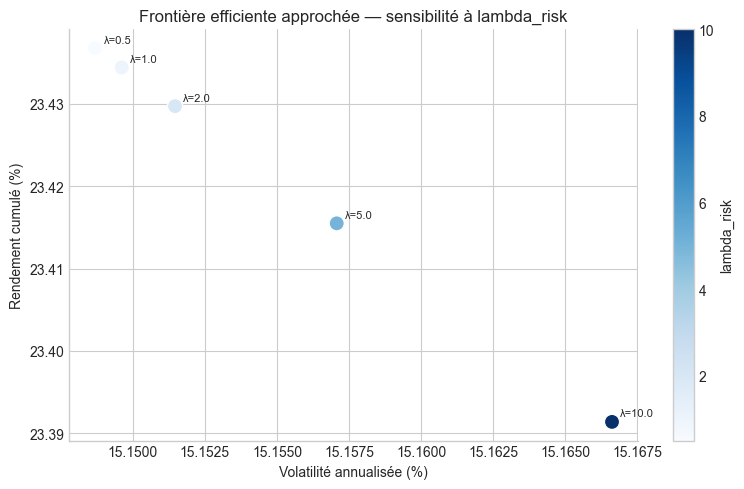

In [21]:
# Frontière efficiente approchée (rendement vs volatilité)
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    sens_df['Volatilité'] * 100,
    sens_df['Rendement cumulé'] * 100,
    c=sens_df.index, cmap='Blues', s=120, zorder=5, edgecolors='white'
)
for lam, row in sens_df.iterrows():
    ax.annotate(f'λ={lam}',
                xy=(row['Volatilité']*100, row['Rendement cumulé']*100),
                xytext=(6, 4), textcoords='offset points', fontsize=8)
plt.colorbar(sc, ax=ax, label='lambda_risk')
ax.set_xlabel('Volatilité annualisée (%)')
ax.set_ylabel('Rendement cumulé (%)')
ax.set_title('Frontière efficiente approchée — sensibilité à lambda_risk')
plt.tight_layout()
plt.show()